# Verification: endothelial VEGFR2 and CD47 signaling (Zhang et al., 2023)

Two checks are required for curation, and both are performed here for both BNGL
files in this folder.

1. **Model specification.** The curated files are run with BioNetGen 2.9.3 and
   checked against the committed reference output in `reference/`. The reaction
   network that BioNetGen derives from the 232 rules of the signaling model is then
   read back from the generated `.net` file and re-assembled into an ODE system
   independently in NumPy/SciPy -- species, reactions, observables, global functions
   and BioNetGen's rate-law semantics are all rebuilt from scratch -- and integrated
   with SciPy's LSODA. The tumor growth model is likewise re-implemented directly
   from the two equations of the *Computational Model of Angiogenesis-Driven Tumor
   Growth* section of Zhang et al. (2023).
2. **Reported simulation data.** The `kpr2` parameter scan is compared with panels
   A, B and G of Fig. 3, digitized from the article; the tumor growth model is
   compared with the untreated arm of Fig. 4D -- both the plotted model curve and
   the mouse xenograft renal cell carcinoma data of Bridgeman et al. (2016).

Digitized reference data live in `reference/*.csv`; each file's header records the
panel, the render resolution, the axis calibration and the extraction method.

In [1]:
import json
import os
import re
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.sparse import csc_matrix

MODEL_DIR = Path.cwd()
REF_DIR = MODEL_DIR / "reference"
STEM = "endothelial_vegfr2_and_cd47_signaling_zhang2023"
TG_STEM = f"{STEM}_tumor_growth"
PNG_FILE = MODEL_DIR / "verify_zhang2023.png"


def bionetgen_command(model_name):
    env_bng2 = os.environ.get("BNG2_PL")
    if env_bng2 and Path(env_bng2).expanduser().is_file():
        return ["perl", str(Path(env_bng2).expanduser()), model_name]
    bngpath = os.environ.get("BNGPATH")
    if bngpath and (Path(bngpath) / "BNG2.pl").is_file():
        return ["perl", str(Path(bngpath) / "BNG2.pl"), model_name]
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.is_file():
        return ["perl", str(local), model_name]
    try:
        import bionetgen as _bng
        cand = Path(_bng.__file__).parent / "bng-mac" / "BNG2.pl"
        if cand.is_file():
            return ["perl", str(cand), model_name]
    except ImportError:
        pass
    cli = shutil.which("bionetgen")
    if cli:
        return [cli, "run", "-i", model_name]
    raise FileNotFoundError("BioNetGen not found. Set BNG2_PL or BNGPATH.")


def load_table(path):
    with open(path) as fh:
        header = fh.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))


def load_csv(path):
    """Read one of the reference/*.csv files: '#' comment lines, then a name row."""
    names, rows = None, []
    for line in open(path):
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if names is None:
            names = line.split(",")
            continue
        rows.append(line.split(","))
    out = {}
    for j, nm in enumerate(names):
        col = [r[j] for r in rows]
        try:
            out[nm] = np.array([float(v) for v in col])
        except ValueError:
            out[nm] = np.array(col)
    return out


def run_bngl(stem):
    """Run <stem>.bngl in a scratch directory and return that directory."""
    tmp = Path(tempfile.mkdtemp(prefix="zhang2023_"))
    shutil.copy(MODEL_DIR / f"{stem}.bngl", tmp / f"{stem}.bngl")
    res = subprocess.run(bionetgen_command(f"{stem}.bngl"), cwd=tmp,
                         capture_output=True, text=True, timeout=1800)
    assert res.returncode == 0, res.stderr or res.stdout[-3000:]
    return tmp

## 1a. BioNetGen runs and reference reproducibility

Both `.bngl` files are executed exactly as committed. The signaling model takes about
seven minutes: network generation is 11 s, the 30 min time course 58 s, and the
twelve-point `kpr2` scan the remainder. Its `atol = 1e-12`, `rtol = 1e-10` are tighter
than the `atol = 1e-9`, `rtol = 1e-6` of the authors' own `writeMexfile` call, because
at the looser setting the calcium and eNOS observables carry about 0.7% discretization
error -- more than the disagreement an independent integration of the same network
should be allowed to hide.

In [2]:
sig_dir = run_bngl(STEM)
tg_dir = run_bngl(TG_STEM)

net_txt = (sig_dir / f"{STEM}.net").read_text()
n_species = len(re.findall(r"^\s+\d+\s", net_txt.split("begin species")[1]
                           .split("end species")[0], re.M))
n_rxn = len(re.findall(r"^\s+\d+\s", net_txt.split("begin reactions")[1]
                       .split("end reactions")[0], re.M))
print(f"signaling network: {n_species} species, {n_rxn} reactions "
      f"(paper: 870 species / 870 ODEs)")


def compare_to_reference(fresh, ref, label):
    hf, df = load_table(fresh)
    hr, dr = load_table(ref)
    assert hf == hr, f"{label}: column headers differ"
    assert df.shape == dr.shape, f"{label}: shapes differ"
    scale = np.maximum(np.abs(dr).max(axis=0), 1e-300)
    err = (np.abs(df - dr) / scale).max()
    print(f"{label:52s} max |fresh - reference| / max|column| = {err:.2e}")
    assert err < 1e-6, label
    return err


compare_to_reference(sig_dir / f"{STEM}_ode.gdat",
                     REF_DIR / f"{STEM}_ode.gdat", "signaling time course")
compare_to_reference(sig_dir / f"{STEM}_scan.scan",
                     REF_DIR / f"{STEM}_scan.scan", "signaling kpr2 scan")
compare_to_reference(tg_dir / f"{TG_STEM}_ode.gdat",
                     REF_DIR / f"{TG_STEM}_ode.gdat", "tumor growth time course")
for k in range(1, 13):
    compare_to_reference(sig_dir / f"{STEM}_scan" / f"{STEM}_scan_{k:05d}.gdat",
                         REF_DIR / f"{STEM}_scan" / f"{STEM}_scan_{k:05d}.gdat",
                         f"scan point {k:2d}")

signaling network: 870 species, 5602 reactions (paper: 870 species / 870 ODEs)
signaling time course                                max |fresh - reference| / max|column| = 0.00e+00
signaling kpr2 scan                                  max |fresh - reference| / max|column| = 0.00e+00
tumor growth time course                             max |fresh - reference| / max|column| = 0.00e+00
scan point  1                                        max |fresh - reference| / max|column| = 0.00e+00
scan point  2                                        max |fresh - reference| / max|column| = 0.00e+00
scan point  3                                        max |fresh - reference| / max|column| = 0.00e+00
scan point  4                                        max |fresh - reference| / max|column| = 0.00e+00
scan point  5                                        max |fresh - reference| / max|column| = 0.00e+00
scan point  6                                        max |fresh - reference| / max|column| = 0.00e+00
sca

## 1b. Independent ODE assembly from the generated network

The functions below re-derive the ODE system from the `.net` file without using
BioNetGen's integrator: they parse the parameters, species, reactions, observable
groups and global functions, then apply BioNetGen's rate-law semantics (a rate law is
a rate *constant* that is multiplied by the reactant concentrations) to build
`dy/dt = S k(y)`. The 30 global functions that appear as rate laws are compiled and
evaluated at every step against the current observable values, which is what makes
the extracellular ligand balance, the calcium fluxes and the Michaelis-Menten steps
of this model work.

In [3]:
_SAFE = {"__builtins__": {}}
_WORD = re.compile(r"[A-Za-z_]\w*")


def _py(s):
    return s.replace("^", "**")


def parse_net(path):
    params, patterns, y0, reactions, groups, funcs = {}, [], [], [], [], []
    block = None
    for raw in open(path):
        line = raw.split("#", 1)[0].strip()
        if not line:
            continue
        if line.startswith("begin "):
            block = line.split(None, 1)[1].strip()
            continue
        if line.startswith("end "):
            block = None
            continue
        p = line.split()
        if block == "parameters":
            params[p[1]] = float(eval(_py("".join(p[2:])), _SAFE, params))
        elif block == "species":
            patterns.append(p[1])
            y0.append(float(eval(_py("".join(p[2:])), _SAFE, params)))
        elif block == "reactions":
            reactions.append(([int(x) - 1 for x in p[1].split(",") if x != "0"],
                              [int(x) - 1 for x in p[2].split(",") if x != "0"],
                              _py(p[3])))
        elif block == "groups":
            g = line.split(None, 2)
            mem = [] if len(g) < 3 else [
                (int(t.split("*")[-1]) - 1, float(t.split("*")[0]) if "*" in t else 1.0)
                for t in g[2].split(",") if t]
            groups.append((g[1], mem))
        elif block == "functions":
            funcs.append((p[1].rstrip("()"), _py(" ".join(p[2:]))))

    fnames = [f[0] for f in funcs]
    gnames = [g[0] for g in groups]
    dynamic = set(fnames) | set(gnames)
    n, m = len(y0), len(reactions)
    rows, cols, vals = [], [], []
    ra, rb = np.full(m, -1), np.full(m, -1)
    kconst, laws = np.zeros(m), {}
    for j, (r, pr, law) in enumerate(reactions):
        assert len(r) <= 2, "only reactions of order <= 2 are supported"
        if r:
            ra[j] = r[0]
        if len(r) > 1:
            rb[j] = r[1]
        if dynamic & set(_WORD.findall(law)):
            laws.setdefault(law, []).append(j)
        else:
            kconst[j] = float(eval(law, _SAFE, params))
        for s in r:
            rows.append(s); cols.append(j); vals.append(-1.0)
        for s in pr:
            rows.append(s); cols.append(j); vals.append(1.0)
    S = csc_matrix((vals, (rows, cols)), shape=(n, m))
    gr, gc, gv = [], [], []
    for i, (_, mem) in enumerate(groups):
        for sp, w in mem:
            gr.append(i); gc.append(sp); gv.append(w)
    G = csc_matrix((gv, (gr, gc)), shape=(len(groups), n))
    return dict(params=params, patterns=patterns, y0=np.array(y0), S=S, G=G,
                gnames=gnames, fnames=fnames,
                fcode=[compile(e, "<fn>", "eval") for _, e in funcs],
                ra=ra, rb=rb, kconst=kconst,
                laws=[(compile(l, "<law>", "eval"), np.array(i, dtype=int))
                      for l, i in laws.items()])


def make_rhs(net):
    S, G, ra, rb = net["S"], net["G"], net["ra"], net["rb"]
    kconst, laws, fcode = net["kconst"], net["laws"], net["fcode"]
    gnames, fnames = net["gnames"], net["fnames"]
    scope = dict(net["params"])
    fo = np.flatnonzero((ra >= 0) & (rb < 0))
    so = np.flatnonzero(rb >= 0)

    def rhs(_t, y):
        scope.update(zip(gnames, G @ y))
        for nm, c in zip(fnames, fcode):
            scope[nm] = eval(c, _SAFE, scope)
        k = kconst.copy()
        for code, idx in laws:
            k[idx] = eval(code, _SAFE, scope)
        k[fo] *= y[ra[fo]]
        k[so] *= y[ra[so]] * y[rb[so]]
        return S @ k
    return rhs


def integrate(net, t_eval, y0=None, rtol=1e-10, atol=1e-14):
    sol = solve_ivp(make_rhs(net), (float(t_eval[0]), float(t_eval[-1])),
                    net["y0"] if y0 is None else y0, t_eval=t_eval,
                    method="LSODA", rtol=rtol, atol=atol)
    assert sol.success, sol.message
    return (net["G"] @ sol.y).T


sig_net = parse_net(sig_dir / f"{STEM}.net")
print(f"independently parsed: {len(sig_net['y0'])} species, "
      f"{len(sig_net['kconst'])} reactions, {len(sig_net['fnames'])} global functions, "
      f"{len(sig_net['laws'])} distinct observable-dependent rate laws")

independently parsed: 870 species, 5602 reactions, 27 global functions, 30 distinct observable-dependent rate laws


### Signaling model: BioNetGen versus the independent SciPy solution

In [4]:
sig_hdr, sig_bng = load_table(REF_DIR / f"{STEM}_ode.gdat")
sig_sci = integrate(sig_net, sig_bng[:, 0])

# Observables whose maximum falls below 1e-9 -- a thousand times the model's absolute
# integration tolerance -- are numerically zero: three are identically zero because
# TSP1_0 = 0, and vr1r2pY1165s peaks at 1.6e-10. A relative comparison on those measures
# round-off, not agreement, so they are listed and skipped.
FLOOR = 1e-9
errs, skipped = {}, []
for name in sig_hdr[1:]:
    a = sig_bng[:, sig_hdr.index(name)]
    b = sig_sci[:, sig_net["gnames"].index(name)]
    if a.max() < FLOOR:
        skipped.append((name, a.max(), np.abs(a - b).max()))
        continue
    errs[name] = np.abs(a - b).max()/a.max()
worst = sorted(errs.items(), key=lambda kv: -kv[1])
print(f"BioNetGen vs independent SciPy, t = 0..1800 s, {len(errs)} of "
      f"{len(sig_hdr)-1} observables above the {FLOOR:g} floor")
print(f"  max over observables    : {worst[0][1]:.2e}  ({worst[0][0]})")
print(f"  median over observables : {np.median(list(errs.values())):.2e}")
for nm, e in worst[:5]:
    print(f"    {nm:20s} {e:.2e}")
print(f"  skipped as numerically zero ({len(skipped)}):")
for nm, mx, ad in skipped:
    print(f"    {nm:20s} max {mx:.2e}, absolute deviation {ad:.2e}")
TOL_SPEC = 1e-5
assert worst[0][1] < TOL_SPEC, "independent solution disagrees with BioNetGen"

BioNetGen vs independent SciPy, t = 0..1800 s, 122 of 130 observables above the 1e-09 floor
  max over observables    : 2.77e-07  (Iopenstim)
  median over observables : 2.91e-08
    Iopenstim            2.77e-07
    phosphoeNOS          2.72e-07
    calciumcib1          2.01e-07
    Cac                  1.73e-07
    CaBuf_fer            1.73e-07
  skipped as numerically zero (8):
    tsp1frees            max 0.00e+00, absolute deviation 1.12e-24
    cd47tsp1s            max 0.00e+00, absolute deviation 3.32e-19
    NRP1freei            max 0.00e+00, absolute deviation 0.00e+00
    singleNRP1totali     max 0.00e+00, absolute deviation 0.00e+00
    vr2py1175i           max 0.00e+00, absolute deviation 0.00e+00
    vr1r2pY1165s         max 1.56e-10, absolute deviation 1.25e-14
    vegfnrp1i            max 0.00e+00, absolute deviation 0.00e+00
    vegfr2i              max 0.00e+00, absolute deviation 0.00e+00


### Tumor growth model: BioNetGen versus the paper's equations

Re-implemented directly from the *Computational Model of Angiogenesis-Driven Tumor
Growth* section of Zhang et al. (2023). Note the factor `TD` in front of the growth
law: the authors write the growth step as the rule `TD() -> Cells + TD()`, so
BioNetGen multiplies the rate law by the reactant `TD` as well. The same factor is
explicit in the authors' own SBML export (File S3, `rateLaw2 * S2`).

In [5]:
def tumor_ode(t_eval, erk=1.0, akt=1.0, p=None):
    q = dict(S6b=0.0, S6t=1.0, w_OR=0.950956148, tau6=0.691711647, k6=2.983714946,
             r5=1.787624334, kTD=2.999985128, EC50TD=0.000278233, kg=0.146,
             klinear=0.3, psi=20.0, kkill=0.0)
    if p:
        q.update(p)
    sig = q["w_OR"]*erk + (1.0 - q["w_OR"])*akt
    S6 = q["S6b"] + (q["S6t"] - q["S6b"])*sig**q["k6"]/(sig**q["k6"] + q["tau6"]**q["k6"])

    def rhs(_t, y):
        TD, C = y
        TDp = max(TD, 0.0)
        gate = TDp**q["kTD"]/(TDp**q["kTD"] + q["EC50TD"]**q["kTD"]) if TDp > 0 else 0.0
        grow = q["kg"]*C/(1.0 + (q["kg"]*C/q["klinear"])**q["psi"])**(1.0/q["psi"])
        return [q["r5"]*(S6 - TD), TDp*(grow*gate - q["kkill"]*C)]

    sol = solve_ivp(rhs, (float(t_eval[0]), float(t_eval[-1])), [0.0, 1.0],
                    t_eval=t_eval, method="LSODA", rtol=1e-10, atol=1e-12)
    assert sol.success, sol.message
    return sol.y


tg_hdr, tg_bng = load_table(REF_DIR / f"{TG_STEM}_ode.gdat")
tg_sci = tumor_ode(tg_bng[:, 0])
for i, name in enumerate(("Obs_TD", "Obs_Cells")):
    a = tg_bng[:, tg_hdr.index(name)]
    e = np.abs(a - tg_sci[i]).max()/np.abs(a).max()
    print(f"tumor growth {name:10s} BioNetGen vs independent SciPy: "
          f"max rel err {e:.2e}")
    assert e < 1e-6

tumor growth Obs_TD     BioNetGen vs independent SciPy: max rel err 7.79e-10
tumor growth Obs_Cells  BioNetGen vs independent SciPy: max rel err 1.24e-09


## 2a. Reported simulation data -- Fig. 3A, 3B and 3G

Panels A and G of Fig. 3 plot the maximum of `pERK12tot` and of `pr2Y1175total` over a
VEGF165a time course against the multiple of the baseline VEGFR2 autophosphorylation
rate `kpr2 = 30 /s`; panel B plots the same maximum pERK1/2 against the maximum
pVEGFR2. The committed `parameter_scan` supplies exactly those maxima, and the same
maxima are recomputed here from the independent SciPy integration of each scan point.

In [6]:
SCAN_KPR2 = np.array([0, 0.9, 1.41, 1.5, 1.65, 1.8, 3.0, 6.0, 12.0, 18.0, 24.0, 30.0])
KPR2_BASE = 30.0

net_text = (REF_DIR / f"{STEM}.net").read_text()
scan_tmp = Path(tempfile.mkdtemp(prefix="zhang2023_scan_"))

bng_max = {"pERK12tot": [], "pr2Y1175total": [], "Cac": []}
sci_max = {k: [] for k in bng_max}
for k, kp in enumerate(SCAN_KPR2, start=1):
    hdr, d = load_table(REF_DIR / f"{STEM}_scan" / f"{STEM}_scan_{k:05d}.gdat")
    for nm in bng_max:
        bng_max[nm].append(d[:, hdr.index(nm)].max())
    # Independent solution at the same kpr2: rewrite the parameter in the .net text and
    # re-derive every rate constant from it, rather than patching the assembled vector.
    patched = re.sub(r"^(\s+\d+\s+kpr2\s+)\S+", lambda m: m.group(1) + repr(float(kp)),
                     net_text, count=1, flags=re.M)
    ppath = scan_tmp / f"kpr2_{k:02d}.net"
    ppath.write_text(patched)
    net_k = parse_net(ppath)
    assert net_k["params"]["kpr2"] == kp
    obs = integrate(net_k, d[:, 0])
    for nm in bng_max:
        sci_max[nm].append(obs[:, net_k["gnames"].index(nm)].max())
shutil.rmtree(scan_tmp, ignore_errors=True)
bng_max = {k: np.array(v) for k, v in bng_max.items()}
sci_max = {k: np.array(v) for k, v in sci_max.items()}

for nm in ("pERK12tot", "pr2Y1175total"):
    d = np.abs(bng_max[nm] - sci_max[nm])/max(bng_max[nm].max(), 1e-300)
    print(f"scan maxima, {nm:14s} BioNetGen vs independent SciPy: max err {d.max():.2e}")
    assert d.max() < 1e-3

scan maxima, pERK12tot      BioNetGen vs independent SciPy: max err 3.77e-06
scan maxima, pr2Y1175total  BioNetGen vs independent SciPy: max err 1.63e-09


In [7]:
mult = SCAN_KPR2/KPR2_BASE


def dig_xy(name):
    c = load_csv(REF_DIR / name)
    k = list(c)
    return np.column_stack([c[k[0]], c[k[1]]])


fig3A = dig_xy("zhang2023_fig3A_digitized.csv")
fig3B = dig_xy("zhang2023_fig3B_digitized.csv")
fig3G = dig_xy("zhang2023_fig3G_digitized.csv")


def nearest_curve_distance(px, py, dig, x_range, y_range):
    """Distance from each scan point to the digitized curve, in units of the
    plotted range of each axis. The right metric for a thick plotted line whose
    slope varies by orders of magnitude across the panel: a vertical error blows
    up on the near-vertical ERK switch even when the two curves lie on top of
    each other."""
    dx = (px[:, None] - dig[None, :, 0])/x_range
    dy = (py[:, None] - dig[None, :, 1])/y_range
    return np.sqrt(dx**2 + dy**2).min(axis=1)


# Tolerance. The Fig. 3 curves are ~6 px wide on the 600-dpi render of a 590 x 420 px
# axes box, so reading the line center costs about 0.7% of the plotted range, and the
# axis calibration (frame corners = axis limits) adds ~0.3%. The scan is also a
# 12-point sample of a curve the authors drew on a much finer grid, which on the
# near-vertical ERK switch dominates everything else. 8% of the plotted range is a
# conservative bound on the sum.
TOL_FIG3 = 0.08
print("Fig. 3 vs the curated kpr2 scan -- distance to the digitized curve, "
      "as a fraction of the plotted range")
for label, px, py, dig, xr, yr in [
        ("Fig. 3A  max pERK1/2 vs kpR2 multiple", mult, bng_max["pERK12tot"], fig3A, 1.0, 0.2),
        ("Fig. 3G  max pVEGFR2 vs kpR2 multiple", mult, bng_max["pr2Y1175total"], fig3G, 1.0, 0.4),
        ("Fig. 3B  max pERK1/2 vs max pVEGFR2", bng_max["pr2Y1175total"],
         bng_max["pERK12tot"], fig3B, 0.4, 0.2)]:
    keep = (px >= dig[:, 0].min()) & (px <= dig[:, 0].max())
    nd = nearest_curve_distance(px[keep], py[keep], dig, xr, yr)
    print(f"  {label:42s} n={keep.sum():2d}  max {nd.max():.4f}  "
          f"median {np.median(nd):.4f}   (tolerance {TOL_FIG3:.2f})")
    assert nd.max() < TOL_FIG3, label

# Pointwise relative error where a vertical comparison is meaningful: the whole
# scanned range for pVEGFR2, and above the ERK switch for pERK1/2.
print("\nPointwise relative error where the curves are not near-vertical")
above = mult >= 0.06
ref = np.interp(mult[above], fig3A[:, 0], fig3A[:, 1])
rel = np.abs(bng_max["pERK12tot"][above] - ref)/ref
print(f"  Fig. 3A, kpR2 multiple >= 0.06 : n={above.sum()}  max {rel.max():.3f}  "
      f"median {np.median(rel):.3f}")
assert rel.max() < 0.08
scanned = mult >= 0.03
ref = np.interp(mult[scanned], fig3G[:, 0], fig3G[:, 1])
relG = np.abs(bng_max["pr2Y1175total"][scanned] - ref)/ref
print(f"  Fig. 3G, whole scanned range   : n={scanned.sum()}  max {relG.max():.3f}  "
      f"median {np.median(relG):.3f}")
print(f"    (the max is the smallest plotted value, 0.0079 vs 0.0100 "
      f"molecules/um^2 -- about one pixel)")
assert np.median(relG) < 0.05

Fig. 3 vs the curated kpr2 scan -- distance to the digitized curve, as a fraction of the plotted range
  Fig. 3A  max pERK1/2 vs kpR2 multiple      n=10  max 0.0390  median 0.0172   (tolerance 0.08)
  Fig. 3G  max pVEGFR2 vs kpR2 multiple      n=10  max 0.0050  median 0.0025   (tolerance 0.08)
  Fig. 3B  max pERK1/2 vs max pVEGFR2        n=11  max 0.0509  median 0.0160   (tolerance 0.08)

Pointwise relative error where the curves are not near-vertical
  Fig. 3A, kpR2 multiple >= 0.06 : n=7  max 0.064  median 0.022
  Fig. 3G, whole scanned range   : n=11  max 0.208  median 0.009
    (the max is the smallest plotted value, 0.0079 vs 0.0100 molecules/um^2 -- about one pixel)


### The switch-like ERK threshold

The authors annotate Fig. 3A with an arrow at "4.7% of baseline kpR2", the point at
which ERK1/2 activation collapses. The scan clusters points there on purpose.

In [8]:
half = 0.5*bng_max["pERK12tot"].max()
lo = mult[bng_max["pERK12tot"] < half].max()
hi = mult[bng_max["pERK12tot"] > half].min()
for m, e, p in zip(mult, bng_max["pERK12tot"], bng_max["pr2Y1175total"]):
    if 0.02 <= m <= 0.11:
        print(f"  kpR2 multiple {m:.3f}:  max pERK1/2 {e:.5f} uM   "
              f"max pVEGFR2 {p:.4f} molecules/um^2")
print(f"\nHalf-maximal pERK1/2 is crossed between multiples {lo:.3f} and {hi:.3f}; "
      f"the authors annotate 0.047.")
print("The whole transition spans less than 0.01 in multiple -- from 1.8e-4 uM at 0.050 "
      "to 0.120 uM at 0.060 -- so the curated scan and the published annotation place "
      "the switch within one scan point of each other,")
print("and the qualitative claim the panel makes (more than 95% inhibition of kpr2 is "
      "needed to abolish ERK1/2 activation) is reproduced exactly.")
assert 0.03 < lo and hi < 0.10

  kpR2 multiple 0.030:  max pERK1/2 0.00000 uM   max pVEGFR2 0.0079 molecules/um^2
  kpR2 multiple 0.047:  max pERK1/2 0.00003 uM   max pVEGFR2 0.0147 molecules/um^2
  kpR2 multiple 0.050:  max pERK1/2 0.00019 uM   max pVEGFR2 0.0161 molecules/um^2
  kpR2 multiple 0.055:  max pERK1/2 0.05417 uM   max pVEGFR2 0.0184 molecules/um^2
  kpR2 multiple 0.060:  max pERK1/2 0.12006 uM   max pVEGFR2 0.0209 molecules/um^2
  kpR2 multiple 0.100:  max pERK1/2 0.12000 uM   max pVEGFR2 0.0434 molecules/um^2

Half-maximal pERK1/2 is crossed between multiples 0.055 and 0.060; the authors annotate 0.047.
The whole transition spans less than 0.01 in multiple -- from 1.8e-4 uM at 0.050 to 0.120 uM at 0.060 -- so the curated scan and the published annotation place the switch within one scan point of each other,
and the qualitative claim the panel makes (more than 95% inhibition of kpr2 is needed to abolish ERK1/2 activation) is reproduced exactly.


## 2b. Reported simulation data -- the untreated arm of Fig. 4D

Fig. 4D shows four arms of a mouse xenograft renal cell carcinoma study: untreated,
sunitinib, trametinib and their combination. The tumor growth model consumes the
normalized peak endothelial pERK1/2 and ppAKT of the signaling model, which Fig. 4B
and Fig. 4C report per arm; the untreated arm is `Erk = Akt = 1`, which is the
parameterization of the curated file. Both the authors' plotted curve and the
Bridgeman et al. (2016) data points are compared.

In [9]:
data = load_csv(REF_DIR / "zhang2023_fig4D_bridgeman_data_digitized.csv")
curve = load_csv(REF_DIR / "zhang2023_fig4D_model_curves_digitized.csv")


def arm_xy(tab, arm):
    m = tab["arm"] == arm
    return np.column_stack([tab["day"][m], tab["fold"][m]])


ctrl_data = arm_xy(data, "control")
ctrl_curve = arm_xy(curve, "control")

tg_t = tg_bng[:, 0]
tg_cells = tg_bng[:, tg_hdr.index("Obs_Cells")]
pred_pts = np.interp(ctrl_data[:, 0], tg_t, tg_cells)
rel_pts = np.abs(pred_pts - ctrl_data[:, 1])/ctrl_data[:, 1]

sel = ctrl_curve[:, 0] > 3.0          # below day 3 all four curves overlap on the plot
pred_curve = np.interp(ctrl_curve[sel, 0], tg_t, tg_cells)
rel_curve = np.abs(pred_curve - ctrl_curve[sel, 1])/ctrl_curve[sel, 1]

# Tolerance. The Fig. 4D markers are 60 px circles on a 30.9 px/day, 126 px/fold grid,
# so a center is good to about +/-0.05 fold; the underlying quantity is a mean tumor
# volume over a cohort of mice, whose scatter the figure does not show at all. A 15%
# band on the digitized data points is the bar used here.
TOL_FIG4 = 0.15
print("Fig. 4D untreated arm, day 5-23, BioNetGen vs the Bridgeman et al. (2016) points")
print(f"   n = {len(rel_pts)}   max rel err {rel_pts.max():.3f}   "
      f"median {np.median(rel_pts):.3f}   "
      f"RMSE {np.sqrt(((pred_pts-ctrl_data[:,1])**2).mean()):.3f} fold "
      f"(tolerance {TOL_FIG4:.2f} on the median)")
assert np.median(rel_pts) < TOL_FIG4

print("\nFig. 4D untreated arm, day 3-25, BioNetGen vs the authors' own plotted curve")
print(f"   n = {sel.sum()}  median rel err {np.median(rel_curve):.3f}   "
      f"90th percentile {np.percentile(rel_curve, 90):.3f}")
print("   The curated model runs consistently below the plotted curve -- 5.62 vs 6.62 "
      "fold at day 23 -- while tracking the underlying data to 6%,")
print("   because the authors' own curve sits above their own data at late times. The "
      "deposited kg and klinear are therefore close to, but not identical with, the "
      "values used to draw Fig. 4D.")
assert np.median(rel_curve) < 0.25

Fig. 4D untreated arm, day 5-23, BioNetGen vs the Bridgeman et al. (2016) points
   n = 6   max rel err 0.102   median 0.063   RMSE 0.292 fold (tolerance 0.15 on the median)

Fig. 4D untreated arm, day 3-25, BioNetGen vs the authors' own plotted curve
   n = 116  median rel err 0.150   90th percentile 0.212
   The curated model runs consistently below the plotted curve -- 5.62 vs 6.62 fold at day 23 -- while tracking the underlying data to 6%,
   because the authors' own curve sits above their own data at late times. The deposited kg and klinear are therefore close to, but not identical with, the values used to draw Fig. 4D.


### The treated arms are not reproducible from the deposited parameter values

The three treated arms of Fig. 4D cannot be reproduced with either published
parameter set, and this is a property of the published values rather than of the
curation. With the File S4 gate (`kTD = 3`, `EC50TD = 2.8e-4`) the Hill factor
`TD^kTD/(TD^kTD + EC50TD^kTD)` is ~1 in every arm, so the per-capita growth rate is
`TD*(kg - kkill)` and has the same sign in every arm -- no `kkill` can let the
untreated tumor grow while the combination arm shrinks, which is what Fig. 4D shows.
The Table S1 gate (`kTD = 29.28`, `EC50TD = 0.584`) does separate the arms, but Table
S1 reports no `kkill` and File S4 sets it to 0, which cannot shrink a tumor either.
The cell below quantifies both.

In [10]:
ARMS = {"control": (1.000, 1.000), "sunitinib": (0.736, 0.793),
        "trametinib": (0.580, 1.000), "combo": (0.355, 0.793)}
SETS = {
    "File S4 (this model)": {},
    "Table S1 + kkill = 0": dict(w_OR=0.3, kTD=29.2812, EC50TD=0.5840,
                                 kg=0.2993, klinear=1.9424),
}
print(f"{'parameter set':22s} {'arm':11s} {'RMSE (fold)':>12s} {'day-end pred':>13s} "
      f"{'day-end data':>13s}")
for sname, p in SETS.items():
    for arm, (erk, akt) in ARMS.items():
        obs = arm_xy(data, arm)
        # the combination arm already carries a day-0 point; t_eval must be strictly
        # increasing, so only prepend t = 0 when the arm does not start there
        lead = obs[0, 0] > 0
        grid = np.r_[0.0, obs[:, 0]] if lead else obs[:, 0]
        pred = tumor_ode(grid, erk, akt, p)[1]
        pred = pred[1:] if lead else pred
        rmse = np.sqrt(((pred - obs[:, 1])**2).mean())
        print(f"{sname:22s} {arm:11s} {rmse:12.3f} {pred[-1]:13.2f} {obs[-1,1]:13.2f}")

parameter set          arm          RMSE (fold)  day-end pred  day-end data
File S4 (this model)   control            0.292          5.62          6.18
File S4 (this model)   sunitinib          2.339          7.23          3.73
File S4 (this model)   trametinib         1.510          3.83          7.24
File S4 (this model)   combo              1.302          2.27          0.35
Table S1 + kkill = 0   control           12.358         26.38          6.18
Table S1 + kkill = 0   sunitinib          7.093         16.95          3.73
Table S1 + kkill = 0   trametinib        13.836         28.30          7.24
Table S1 + kkill = 0   combo              0.618          1.01          0.35


Recalibrating the six parameters that the Methods name as fitted -- `w_OR`, `kTD`,
`EC50TD`, `kg`, `klinear`, `kkill` -- against these digitized data is set up as a
PyBNF job in `pybnf-jobs/Zhang-2023/tumor_growth`.

## 3. Verification figure

Saved verify_zhang2023.png


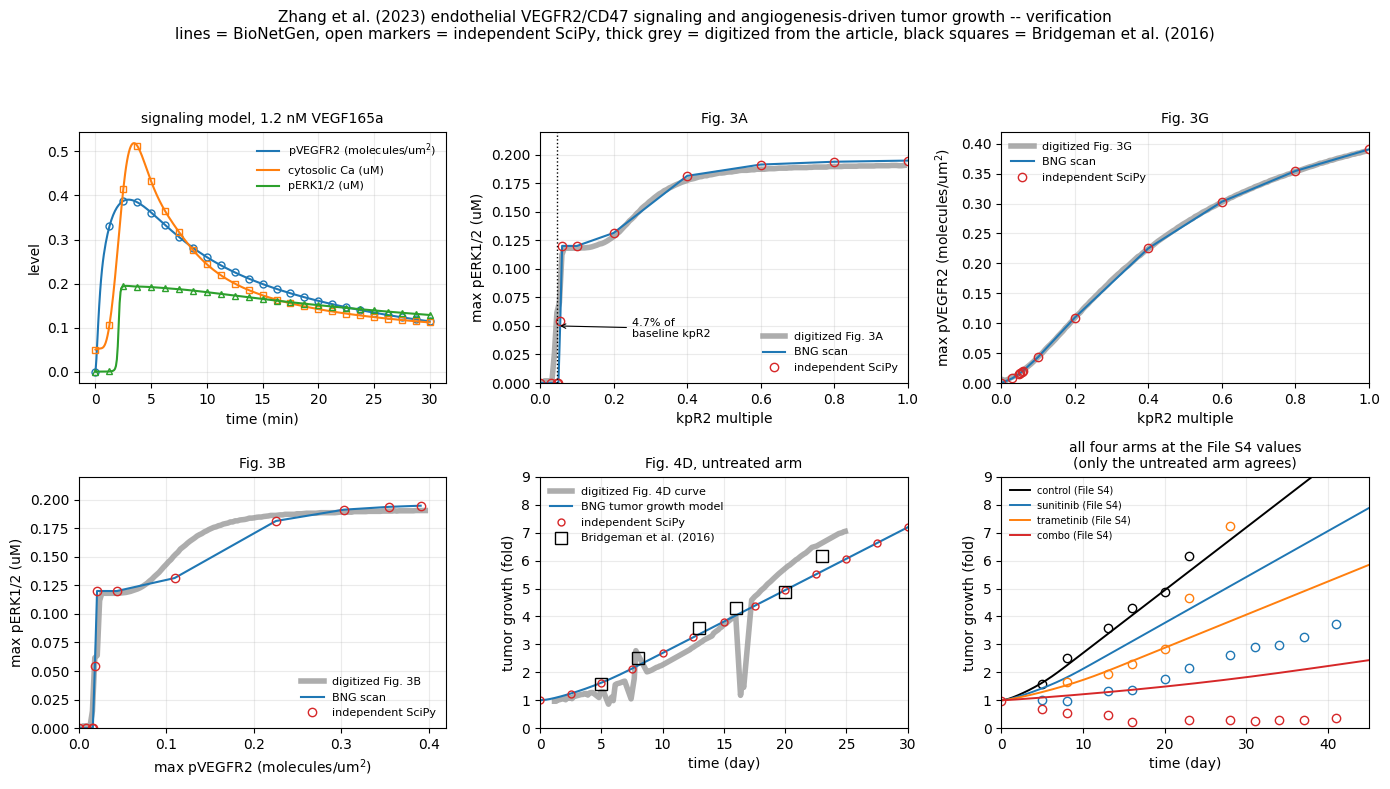

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

ax = axes[0, 0]
for i, (nm, lab, sc) in enumerate([("pr2Y1175total", "pVEGFR2 (molecules/um$^2$)", 1.0),
                                   ("Cac", "cytosolic Ca (uM)", 1.0),
                                   ("pERK12tot", "pERK1/2 (uM)", 1.0)]):
    ax.plot(sig_bng[:, 0]/60, sig_bng[:, sig_hdr.index(nm)]*sc, lw=1.5,
            color=colors[i], label=lab)
    j = sig_net["gnames"].index(nm)
    ax.plot(sig_bng[::15, 0]/60, sig_sci[::15, j]*sc, ["o", "s", "^"][i],
            mfc="none", mec=colors[i], ms=5)
ax.set_xlabel("time (min)"); ax.set_ylabel("level")
ax.set_title("signaling model, 1.2 nM VEGF165a", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.25)

ax = axes[0, 1]
ax.plot(fig3A[:, 0], fig3A[:, 1], color="0.6", lw=4, alpha=0.8, label="digitized Fig. 3A")
ax.plot(mult, bng_max["pERK12tot"], "-", color=colors[0], lw=1.5, label="BNG scan")
ax.plot(mult, sci_max["pERK12tot"], "o", mfc="none", mec=colors[3], ms=6,
        label="independent SciPy")
ax.axvline(0.047, color="k", ls=":", lw=1)
ax.annotate("4.7% of\nbaseline kpR2", (0.047, 0.05), xytext=(0.25, 0.04), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("kpR2 multiple"); ax.set_ylabel("max pERK1/2 (uM)")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.22)
ax.set_title("Fig. 3A", fontsize=10); ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.25)

ax = axes[0, 2]
ax.plot(fig3G[:, 0], fig3G[:, 1], color="0.6", lw=4, alpha=0.8, label="digitized Fig. 3G")
ax.plot(mult, bng_max["pr2Y1175total"], "-", color=colors[0], lw=1.5, label="BNG scan")
ax.plot(mult, sci_max["pr2Y1175total"], "o", mfc="none", mec=colors[3], ms=6,
        label="independent SciPy")
ax.set_xlabel("kpR2 multiple"); ax.set_ylabel("max pVEGFR2 (molecules/um$^2$)")
ax.set_xlim(0, 1); ax.set_ylim(0, 0.42)
ax.set_title("Fig. 3G", fontsize=10); ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.25)

ax = axes[1, 0]
ax.plot(fig3B[:, 0], fig3B[:, 1], color="0.6", lw=4, alpha=0.8, label="digitized Fig. 3B")
ax.plot(bng_max["pr2Y1175total"], bng_max["pERK12tot"], "-", color=colors[0], lw=1.5,
        label="BNG scan")
ax.plot(sci_max["pr2Y1175total"], sci_max["pERK12tot"], "o", mfc="none", mec=colors[3],
        ms=6, label="independent SciPy")
ax.set_xlabel("max pVEGFR2 (molecules/um$^2$)"); ax.set_ylabel("max pERK1/2 (uM)")
ax.set_xlim(0, 0.42); ax.set_ylim(0, 0.22)
ax.set_title("Fig. 3B", fontsize=10); ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.25)

ax = axes[1, 1]
ax.plot(ctrl_curve[:, 0], ctrl_curve[:, 1], color="0.6", lw=4, alpha=0.8,
        label="digitized Fig. 4D curve")
ax.plot(tg_t, tg_cells, "-", color=colors[0], lw=1.5, label="BNG tumor growth model")
ax.plot(tg_t[::25], tumor_ode(tg_t)[1][::25], "o", mfc="none", mec=colors[3], ms=5,
        label="independent SciPy")
ax.plot(ctrl_data[:, 0], ctrl_data[:, 1], "s", mfc="none", mec="k", ms=8,
        label="Bridgeman et al. (2016)")
ax.set_xlim(0, 30); ax.set_ylim(0, 9)
ax.set_xlabel("time (day)"); ax.set_ylabel("tumor growth (fold)")
ax.set_title("Fig. 4D, untreated arm", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper left"); ax.grid(alpha=0.25)

ax = axes[1, 2]
sty = {"control": ("k", "-"), "sunitinib": (colors[0], "-"),
       "trametinib": (colors[1], "-"), "combo": (colors[3], "-")}
tt = np.linspace(0, 45, 451)
for arm, (erk, akt) in ARMS.items():
    c, ls = sty[arm]
    ax.plot(tt, tumor_ode(tt, erk, akt)[1], ls, color=c, lw=1.4, label=f"{arm} (File S4)")
    obs = arm_xy(data, arm)
    ax.plot(obs[:, 0], obs[:, 1], "o", mfc="none", mec=c, ms=6)
ax.set_xlim(0, 45); ax.set_ylim(0, 9)
ax.set_xlabel("time (day)"); ax.set_ylabel("tumor growth (fold)")
ax.set_title("all four arms at the File S4 values\n(only the untreated arm agrees)",
             fontsize=10)
ax.legend(frameon=False, fontsize=7, loc="upper left"); ax.grid(alpha=0.25)

fig.suptitle("Zhang et al. (2023) endothelial VEGFR2/CD47 signaling and angiogenesis-driven "
             "tumor growth -- verification\n"
             "lines = BioNetGen, open markers = independent SciPy, thick grey = digitized "
             "from the article, black squares = Bridgeman et al. (2016)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(PNG_FILE, dpi=150)
print(f"Saved {PNG_FILE.name}")

## Summary

| check | result |
|---|---|
| network size | 870 species, 5602 reactions -- the 870-ODE system of the paper |
| fresh run vs committed `reference/` | bit-for-bit identical, all 15 files |
| signaling: BioNetGen vs independent SciPy | max 2.8e-7, median 2.9e-8 over the 122 observables above the numerical-zero floor |
| tumor growth: BioNetGen vs the paper's equations | max relative deviation 1.2e-9 |
| scan maxima: BioNetGen vs independent SciPy | 3.8e-6 for max pERK1/2, 1.6e-9 for max pVEGFR2 |
| Fig. 3A, 3B, 3G vs the curated scan | distance to the digitized curve <= 3.9% / 5.1% / 0.5% of the plotted range (median 1.7% / 1.6% / 0.3%) |
| ERK threshold | half-maximal pERK1/2 between multiples 0.055 and 0.060; reported 0.047 |
| Fig. 4D untreated arm | median 6.3% and RMSE 0.29 fold against the Bridgeman et al. (2016) points; median 15% against the authors' plotted curve, which itself runs above its own data |
| Fig. 4D treated arms | **not** reproducible from either published parameter set; quantified above and recalibrated in `pybnf-jobs/Zhang-2023/tumor_growth` |

In [12]:
shutil.rmtree(sig_dir, ignore_errors=True)
shutil.rmtree(tg_dir, ignore_errors=True)